# DBSCAN Clustering — Theory to Implementation

This notebook is the **hands-on companion** to `DBSCAN_Clustering_Notes.md`.
It walks through every concept from the notes, in order, with runnable code:

1. Setup
2. Core Point / Border Point / Noise — manual classification from scratch
3. Effect of `epsilon` on results
4. DBSCAN on moon-shaped data (the notes' main implementation example)
5. DBSCAN vs K-Means vs Hierarchical — non-linear shape showdown
6. Nested / surrounded clusters (DBSCAN's special capability)
7. Choosing `epsilon` systematically — the k-distance graph
8. Key takeaways

> Run the cells top to bottom. Everything here uses only `numpy`, `pandas`, `matplotlib`, and `scikit-learn`.


## 1. Setup — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.datasets import make_moons, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Core Point / Border Point / Noise — Classify Points Manually

Before letting `sklearn` do the work, let's implement the core/border/noise logic
from the notes ourselves, on a small toy dataset, to make sure the concept is crystal clear.

**Recap of the rules (minPts = 4):**
- **Core point**: has ≥ minPts points (including itself) within its ε-radius
- **Border point**: has < minPts points within its own ε-radius, BUT lies within some core point's ε-radius
- **Noise point**: neither of the above

In [2]:
# Small toy dataset: two dense-ish groups + a couple of stray points
np.random.seed(3)
cluster1 = np.random.normal(loc=[2, 2], scale=0.35, size=(18, 2))
cluster2 = np.random.normal(loc=[6, 6], scale=0.35, size=(18, 2))
noise_pts = np.array([[0.2, 6.5], [7.5, 1.0], [4, 4], [1.0, 8.0]])
X_toy = np.vstack([cluster1, cluster2, noise_pts])

print("Dataset shape:", X_toy.shape)


Dataset shape: (40, 2)


In [3]:
def classify_points_manually(X, eps, min_pts):
    """Manual implementation of DBSCAN's core/border/noise classification logic."""
    n = len(X)
    # Step 1: for every point, find how many points fall within eps (including itself)
    neighbor_counts = []
    neighbor_lists = []
    for i in range(n):
        dists = np.linalg.norm(X - X[i], axis=1)
        neighbors = np.where(dists <= eps)[0]
        neighbor_counts.append(len(neighbors))
        neighbor_lists.append(neighbors)

    # Step 2: mark core points
    is_core = np.array([count >= min_pts for count in neighbor_counts])

    # Step 3: classify remaining points as border (if near a core point) or noise
    point_type = np.array(['noise'] * n, dtype=object)
    point_type[is_core] = 'core'

    for i in range(n):
        if point_type[i] == 'core':
            continue
        # is this point within eps of ANY core point?
        for j in neighbor_lists[i]:
            if is_core[j]:
                point_type[i] = 'border'
                break

    return point_type

eps = 0.45
min_pts = 4
point_types = classify_points_manually(X_toy, eps, min_pts)

print("Point type counts:")
print(pd.Series(point_types).value_counts())


Point type counts:
core      27
noise      7
border     6
Name: count, dtype: int64


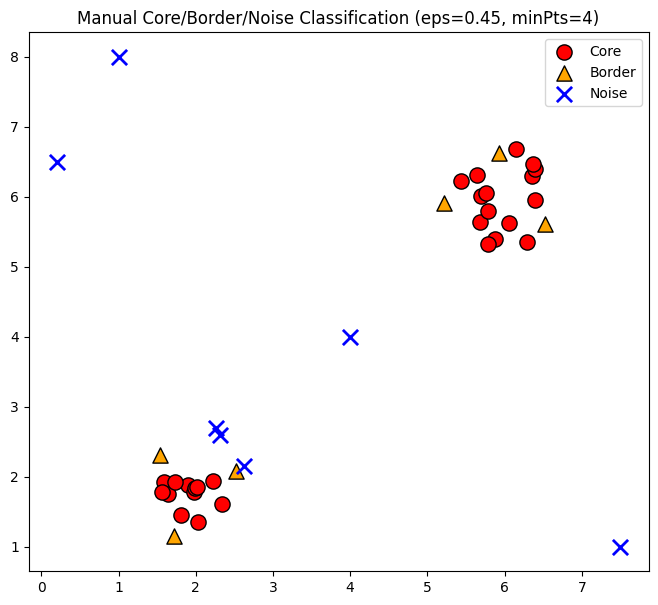

In [4]:
colors = {'core': 'red', 'border': 'orange', 'noise': 'blue'}
markers = {'core': 'o', 'border': '^', 'noise': 'x'}

fig, ax = plt.subplots(figsize=(8, 7))
for ptype in ['core', 'border', 'noise']:
    mask = point_types == ptype
    ax.scatter(X_toy[mask, 0], X_toy[mask, 1], s=120, c=colors[ptype],
               marker=markers[ptype], edgecolor='black' if ptype != 'noise' else None,
               linewidths=2 if ptype == 'noise' else 1, label=ptype.capitalize())

ax.set_title(f'Manual Core/Border/Noise Classification (eps={eps}, minPts={min_pts})')
ax.legend()
plt.show()


Now let's confirm our manual implementation matches `sklearn`'s `DBSCAN`:

In [5]:
db_check = DBSCAN(eps=eps, min_samples=min_pts).fit(X_toy)
sklearn_core_mask = np.zeros(len(X_toy), dtype=bool)
sklearn_core_mask[db_check.core_sample_indices_] = True

our_core_mask = point_types == 'core'
print("Our manual core points match sklearn's core points:", np.array_equal(our_core_mask, sklearn_core_mask))


Our manual core points match sklearn's core points: True


## 3. Effect of Epsilon on Results

Let's reproduce the notes' 3-panel demonstration: epsilon too small, just right, and too large.

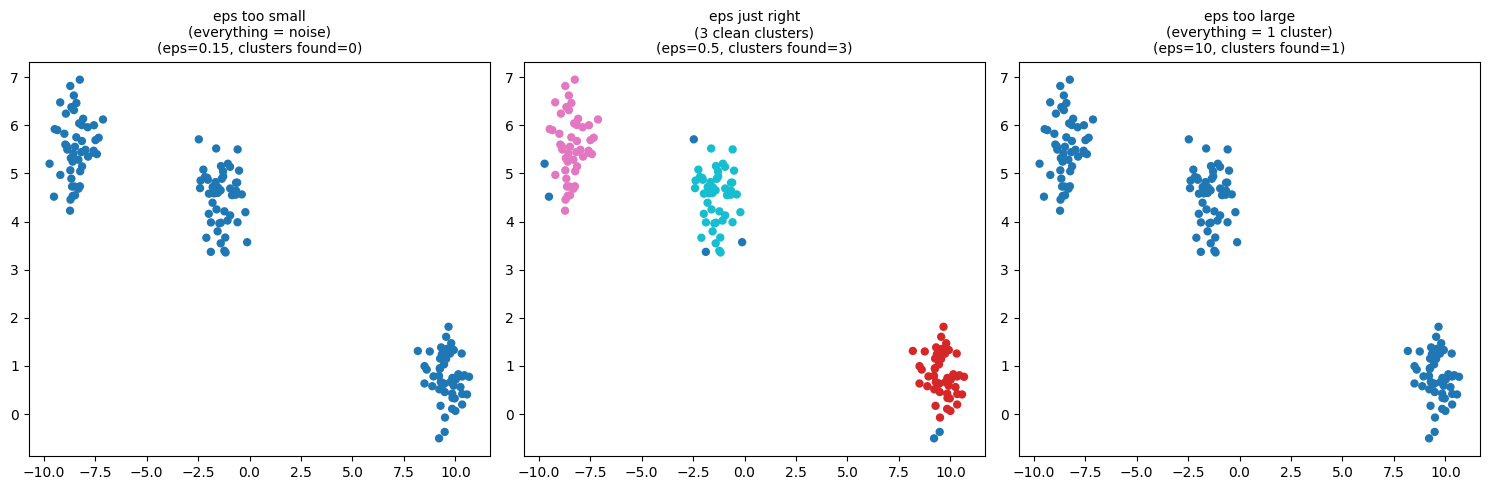

In [6]:
X_blobs, _ = make_blobs(n_samples=150, centers=3, cluster_std=0.6, random_state=7)

eps_values = [0.15, 0.5, 10]
titles = ['eps too small\n(everything = noise)', 'eps just right\n(3 clean clusters)', 'eps too large\n(everything = 1 cluster)']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, eps_v, title in zip(axes, eps_values, titles):
    db = DBSCAN(eps=eps_v, min_samples=5).fit(X_blobs)
    lbls = db.labels_
    n_clusters = len(set(lbls)) - (1 if -1 in lbls else 0)
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=lbls, cmap='tab10', s=25)
    ax.set_title(f"{title}\n(eps={eps_v}, clusters found={n_clusters})", fontsize=10)

plt.tight_layout()
plt.show()


## 4. Full Real-World Pipeline — DBSCAN on Moon-Shaped Data

This reproduces the exact implementation from the notes (Section 11): generate two
interleaving half-moons, scale, apply DBSCAN, and compare against ground truth.

In [7]:
# Step 1: Generate the moon-shaped dataset
X, y = make_moons(n_samples=250, noise=0.05, random_state=42)
print("X shape:", X.shape)


X shape: (250, 2)


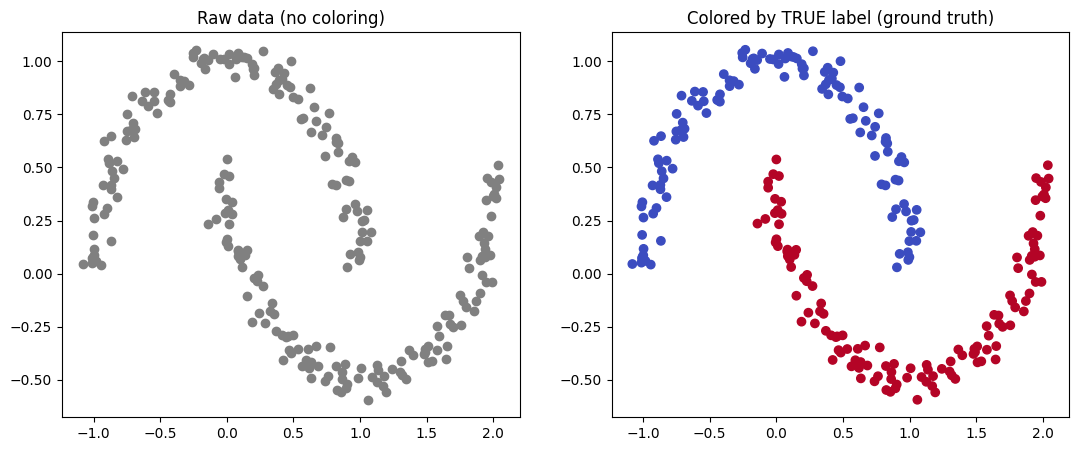

In [8]:
# Step 2: Visualize raw data (with and without true-label coloring)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X[:, 0], X[:, 1], color='gray')
axes[0].set_title('Raw data (no coloring)')
axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
axes[1].set_title('Colored by TRUE label (ground truth)')
plt.show()


In [9]:
# Step 3: Feature scaling -- always required before distance-based clustering
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)


In [10]:
# Step 4: Apply DBSCAN
dbscan = DBSCAN(eps=0.3)
dbscan.fit(X_scaled)

print("Unique labels found:", set(dbscan.labels_))
print("Number of noise points:", (dbscan.labels_ == -1).sum())


Unique labels found: {np.int64(0), np.int64(1)}
Number of noise points: 0


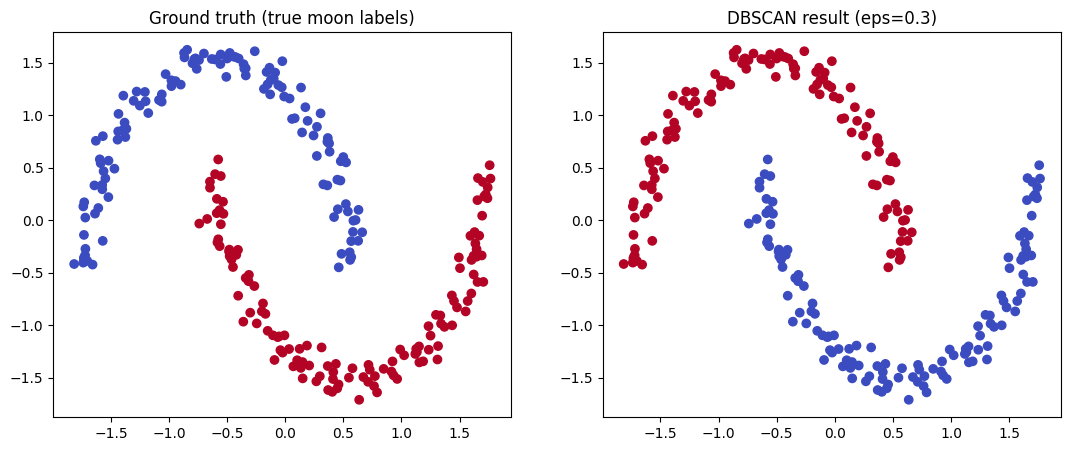

DBSCAN correctly separates the two crescents without ever being told there are 2 groups!


In [11]:
# Step 5: Visualize the DBSCAN result and compare to ground truth
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm')
axes[0].set_title('Ground truth (true moon labels)')
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan.labels_, cmap='coolwarm')
axes[1].set_title('DBSCAN result (eps=0.3)')
plt.show()

print("DBSCAN correctly separates the two crescents without ever being told there are 2 groups!")


## 5. DBSCAN vs K-Means vs Hierarchical — Non-Linear Shape Showdown

Let's put all three algorithms side by side on the same moon-shaped data.

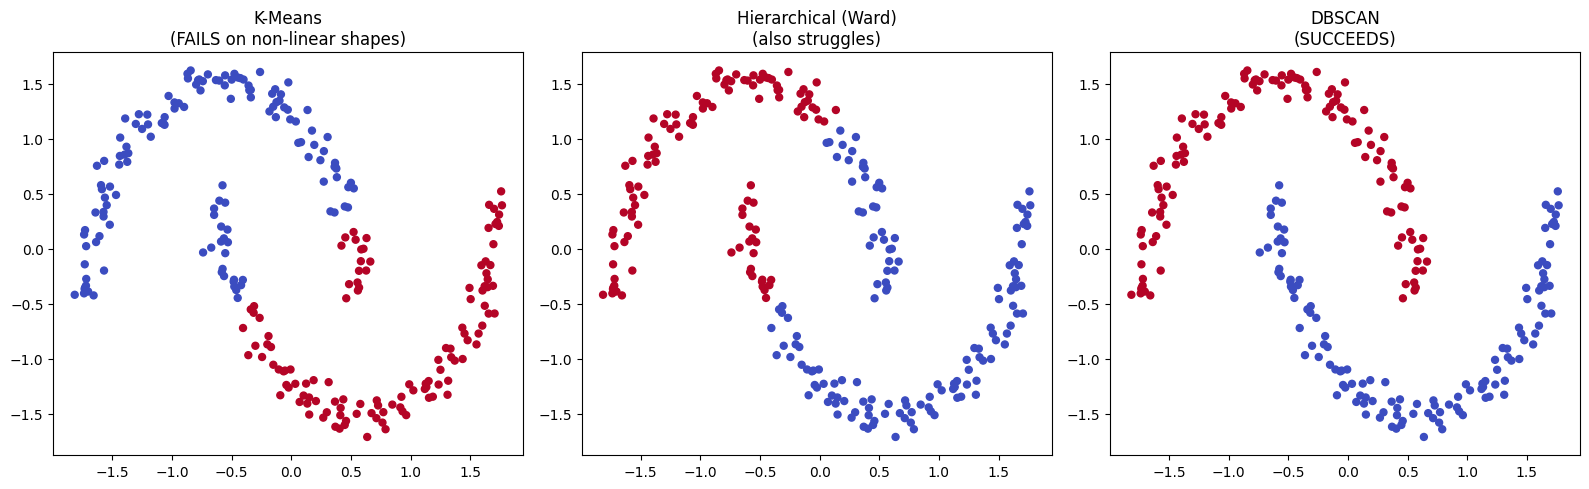

In [12]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

hier = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
hier_labels = hier.fit_predict(X_scaled)

dbscan_labels = dbscan.labels_

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='coolwarm', s=25)
axes[0].set_title('K-Means\n(FAILS on non-linear shapes)')
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=hier_labels, cmap='coolwarm', s=25)
axes[1].set_title('Hierarchical (Ward)\n(also struggles)')
axes[2].scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels, cmap='coolwarm', s=25)
axes[2].set_title('DBSCAN\n(SUCCEEDS)')
plt.tight_layout()
plt.show()


**Observation:** K-Means and Hierarchical Clustering both try to draw straight-ish boundaries and end up splitting each crescent in half, mixing the two true groups. DBSCAN correctly follows the density/shape of each crescent.

## 6. Nested / Surrounded Clusters — DBSCAN's Special Capability

Now let's reproduce the notes' "cluster completely surrounded by another cluster" example
(concentric circles) — something K-Means fundamentally cannot do.

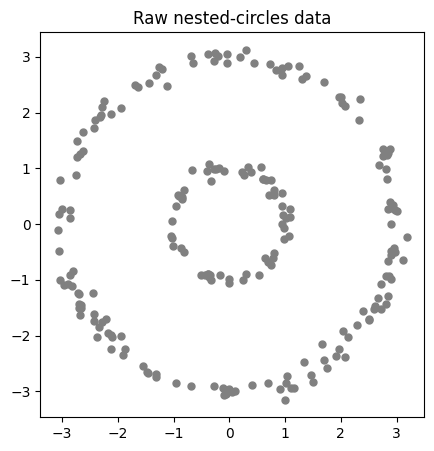

In [13]:
def make_circle(n, radius, noise=0.05):
    theta = np.random.uniform(0, 2*np.pi, n)
    r = radius + np.random.normal(0, noise, n)
    return np.c_[r*np.cos(theta), r*np.sin(theta)]

np.random.seed(1)
inner = make_circle(60, 1.0, noise=0.08)
outer = make_circle(150, 3.0, noise=0.1)
X_nested = np.vstack([inner, outer])

plt.scatter(X_nested[:, 0], X_nested[:, 1], color='gray', s=25)
plt.title('Raw nested-circles data')
plt.gca().set_aspect('equal')
plt.show()


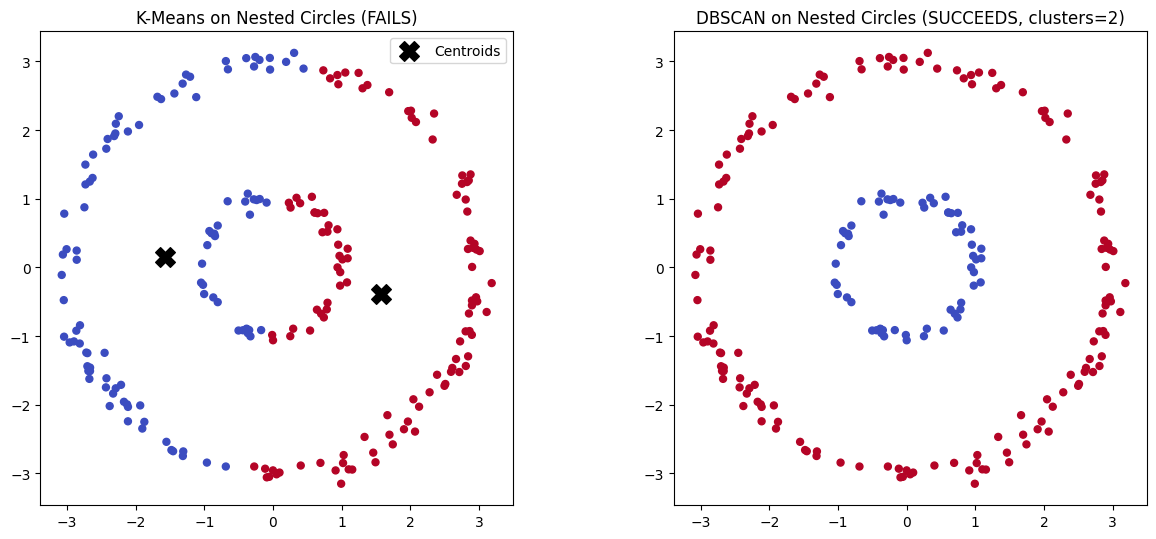

In [14]:
km_nested = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels_nested = km_nested.fit_predict(X_nested)

db_nested = DBSCAN(eps=0.7, min_samples=4).fit(X_nested)
db_labels_nested = db_nested.labels_
n_clusters_nested = len(set(db_labels_nested)) - (1 if -1 in db_labels_nested else 0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].scatter(X_nested[:, 0], X_nested[:, 1], c=km_labels_nested, cmap='coolwarm', s=25)
axes[0].scatter(km_nested.cluster_centers_[:, 0], km_nested.cluster_centers_[:, 1],
                marker='X', s=200, c='black', label='Centroids')
axes[0].set_title('K-Means on Nested Circles (FAILS)')
axes[0].legend()
axes[0].set_aspect('equal')

axes[1].scatter(X_nested[:, 0], X_nested[:, 1], c=db_labels_nested, cmap='coolwarm', s=25)
axes[1].set_title(f'DBSCAN on Nested Circles (SUCCEEDS, clusters={n_clusters_nested})')
axes[1].set_aspect('equal')
plt.tight_layout()
plt.show()


## 7. Choosing Epsilon Systematically — the k-distance Graph

Instead of guessing `epsilon`, a standard technique is the **k-distance graph**:
1. For every point, compute the distance to its k-th nearest neighbor (k = minPts is a common choice).
2. Sort these distances in ascending order and plot them.
3. Look for the **"elbow"** (the point of maximum curvature) — that distance value is a great starting guess for `epsilon`.

**Real-life intuition:** This is conceptually similar to the Elbow Method for K-Means, or the
"longest vertical line" trick for hierarchical clustering's dendrogram -- we're looking for the point
where the data's structure changes most abruptly.

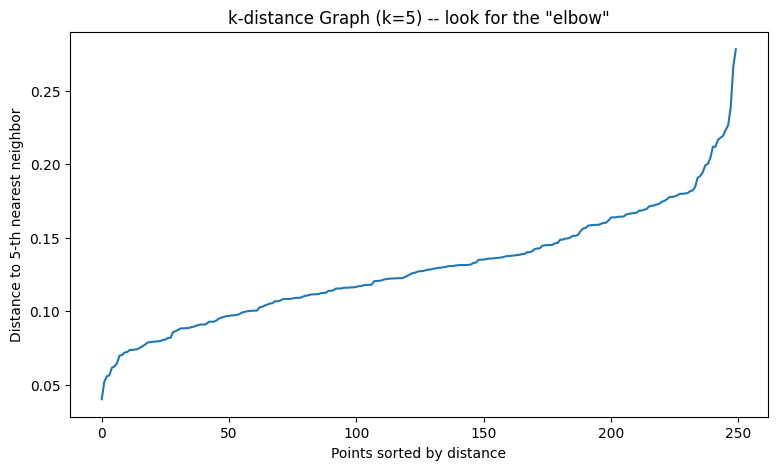

In [15]:
min_pts = 5  # same as minPts we plan to use in DBSCAN

neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# distance to the k-th nearest neighbor for every point, sorted ascending
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances)
plt.title(f'k-distance Graph (k={min_pts}) -- look for the "elbow"')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {min_pts}-th nearest neighbor')
plt.show()


Suggested epsilon from k-distance graph: 0.239


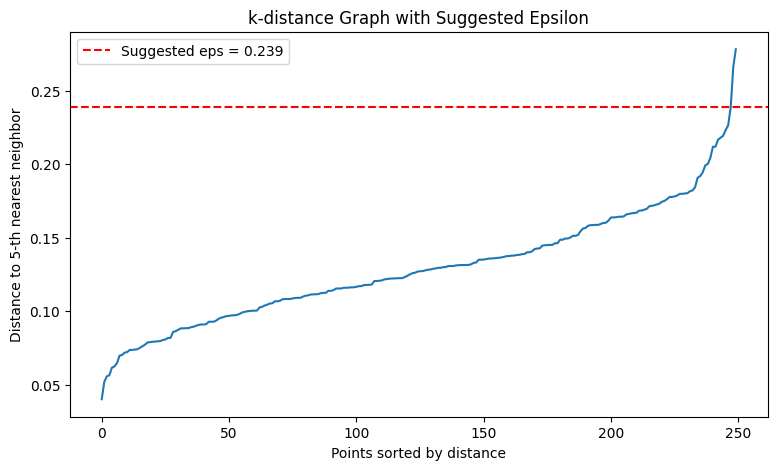

In [16]:
# A simple automated way to find the elbow: point of maximum curvature via second derivative
first_deriv = np.diff(k_distances)
second_deriv = np.diff(first_deriv)
elbow_index = np.argmax(second_deriv) + 1  # +1 to correct for the double-diff offset
suggested_eps = k_distances[elbow_index]

print(f"Suggested epsilon from k-distance graph: {suggested_eps:.3f}")

plt.figure(figsize=(9, 5))
plt.plot(k_distances)
plt.axhline(suggested_eps, color='red', linestyle='--', label=f'Suggested eps = {suggested_eps:.3f}')
plt.title('k-distance Graph with Suggested Epsilon')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {min_pts}-th nearest neighbor')
plt.legend()
plt.show()


In [17]:
# Compare against a silhouette-score sweep over several epsilon candidates
eps_candidates = np.arange(0.1, 0.6, 0.05)
scores = []
for eps_c in eps_candidates:
    labels = DBSCAN(eps=eps_c, min_samples=min_pts).fit_predict(X_scaled)
    if len(set(labels)) > 1 and len(set(labels)) < len(X_scaled):
        # silhouette score needs at least 2 clusters and excludes single-cluster/all-noise cases
        try:
            score = silhouette_score(X_scaled, labels)
        except Exception:
            score = np.nan
    else:
        score = np.nan
    scores.append(score)

results_df = pd.DataFrame({'epsilon': eps_candidates.round(3), 'silhouette_score': np.round(scores, 3)})
results_df


,epsilon,silhouette_score
0,0.10,-0.085
1,0.15,0.398
2,0.20,0.193
3,0.25,0.380
4,0.30,0.380
5,0.35,0.380
6,0.40,0.380
7,0.45,0.380
8,0.50,0.380
9,0.55,0.380


Pick the `epsilon` with the highest silhouette score as your final choice — combining both the k-distance graph (a good starting range) and silhouette scoring (fine-tuning within that range) is a solid systematic approach.

## 8. Key Takeaways (Recap)

- DBSCAN classifies every point as **Core**, **Border**, or **Noise** based on the `epsilon` and `minPts` hyperparameters — we implemented this logic manually and confirmed it matches `sklearn`.
- **Epsilon selection matters a lot**: too small -> all noise; too large -> one giant cluster.
- DBSCAN **outperforms K-Means and Hierarchical Clustering on non-linear shapes** (moons) and can even find a **cluster completely surrounded by another cluster** (nested circles) -- neither of the other two algorithms can do this.
- The **k-distance graph** gives a principled starting point for `epsilon`, which can then be fine-tuned using the **silhouette score**.
- Always **scale your features** before running DBSCAN, exactly like K-Means and Hierarchical Clustering.

### Next
Head to the project notebooks for real-world, end-to-end use cases:
- `Project1_Anomaly_Detection.ipynb`
- `Project2_Geospatial_Hotspot_Detection.ipynb`
- `Project3_NonLinear_Clustering_Showdown.ipynb`
- `Project4_Epsilon_Tuning_kDistance_Graph.ipynb`
